<img src="https://www.pucsp.br/sites/default/files/download/brasao-PUCSP-assinatura-principal-RGB.png" style="float:right;" width="150px">

# Ciências da Computação [》](https://www.pucsp.br/graduacao/ciencia-da-computacao)

## Inteligência Artificial

IA ML (Machine Learning, Aprendizagem de Máquina)

**Objetivo deste LAB explorar os modelos de Regressão Linear e Regressão Logística com Scikit-Learn em Python, sobre os dados de "Happines por idade e país"**

- Regressão Linear: <br>
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

- Regressão Logistica: <br>
https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

# LAB: Felicidade por Idade e por País

> ### Informações da atividade
>
> - **Formato:** projeto em **dupla** pairing - [pair programming](https://en.wikipedia.org/wiki/Pair_programming) (2 estudantes). Os dois participam de todas as etapas e os dois precisam ter commits no repositório.
> - **Prazo:** até o **final do dia** da aula LAB. A atividade **pode ser feita durante a aula de laboratório**.
> - **Publicação:** publiquem o projeto no **GitHub**, como item do **portfólio** da dupla, e enviem o **link do repositório** na **atividade do MS Teams**.

**Dupla**

| | Nome | RA | Usuário no GitHub |
| --- | --- | --- | --- |
| Integrante 1 | Rubens Rodrigues Luiz Sexto de Luiggi Maranesi | RA00331129 | [Rubziguin](https://github.com/Rubziguin) |
| Integrante 2 | Pedro Gabriel Takenobu Serafim | RA00340890 | [pedrogts](https://github.com/pedrogts) |

**Checklist de entrega** (os detalhes estão na Seção 10)

- [ ] O notebook roda de cima para baixo em um kernel limpo (*Restart & Run All*) e foi salvo **com as saídas** (gráficos e tabelas).
- [ ] O repositório no GitHub tem `README.md`, `requirements.txt`, `lab_helpers.py` (opcional) e este notebook.
- [ ] Os dois integrantes têm commits no repositório.
- [ ] O link do repositório foi enviado na atividade do MS Teams.

## 1. Contexto

Neste laboratório vamos testar uma das afirmações mais debatidas na pesquisa sobre felicidade: a de que a satisfação com a vida segue uma **curva em U** ao longo da idade, e de que o formato dessa curva depende de onde a pessoa vive. Vocês vão construir o pipeline completo, dos dados brutos ao modelo ajustado, usando **Python, scikit-learn e Seaborn**.

Pesquisadores medem bem-estar com a **escada de Cantril** (*Cantril ladder*): a pessoa avalia sua vida atual de 0 (pior vida possível) a 10 (melhor vida possível). O **Gallup World Poll** faz essa pergunta em amostras nacionalmente representativas em mais de 140 países, e o **World Happiness Report (WHR)** publica as médias nacionais, em geral como médias móveis de três anos.

Duas histórias concorrentes sobre a idade aparecem nesses dados:

- **A curva em U clássica.** Estudos do Reino Unido e de outros países de renda alta mostram a felicidade caindo a partir dos 20 anos, até os 40 ou início dos 50, e depois subindo até se estabilizar por volta dos 70. As explicações incluem a pressão da meia-idade (emprego, filhos, cuidado com pais idosos) e a adaptação e as expectativas menores na velhice.
- **Um alvo em movimento.** O capítulo sobre idade do WHR 2024 mostra que a felicidade dos jovens (15 a 24 anos) na América do Norte caiu bastante desde 2006-2010, e hoje eles estão menos felizes que os mais velhos. Na Europa Central e Oriental aconteceu o oposto: a felicidade subiu em todas as idades. Quem nasceu depois de 1980 também relata avaliações de vida menores que as coortes anteriores.

*The Happiness Curve* é a versão popular, em formato de livro, da primeira história. O projeto de vocês é ver quanto de cada história sobrevive aos dados, e perceber o que renda, população e área do país mudam nesse quadro.

**Por que isso é um bom exercício de ML.** A pergunta se traduz em duas tarefas supervisionadas clássicas. Prever uma nota (0 a 10) a partir de idade e características do país é **regressão**. Prever se um grupo está acima ou abaixo de um limiar de felicidade é **classificação**. A curva em U também traz uma lição embutida: uma reta é o modelo errado para a idade, e vocês devem ser capazes de mostrar por quê.

## 2. Objetivos de aprendizagem e pré-requisitos

Ao final do laboratório, seremos capazes de construir, avaliar e explicar dois modelos do scikit-learn sobre um conjunto de dados combinado de várias fontes, dizendo com honestidade o que eles mostram e o que não mostram. Organize o tempo de laboratório, mais as leituras. Como o projeto é em dupla, a divisão de trabalho sugerida está abaixo.

Vocês serão capazes de:

- Combinar dados de pesquisa com indicadores do Banco Mundial usando uma chave de país, e auditar o *join* para achar países sem correspondência.
- Criar atributos (*features*) a partir de grandezas assimétricas (log do PIB per capita, log da população, log da área) e explicar o motivo.
- Ajustar uma regressão linear e visualizá-la com Seaborn, mostrando que um termo quadrático na idade supera a reta.
- Transformar uma variável numérica em rótulo binário, ajustar uma regressão logística e embrulhá-la em uma função reutilizável que devolve P(feliz) para uma idade e um país.
- Avaliar com uma divisão **agrupada por país**, para que o modelo seja testado em países que nunca viu.

**Pré-requisitos:** noções de pandas, o padrão `fit` / `predict` do scikit-learn e um laboratório anterior sobre divisão treino/teste.

In [1]:
# Instalação: o Colab já tem pandas, numpy, scikit-learn, seaborn e requests.
# Falta só o country_converter (usado por to_iso3).
%pip install -q country_converter openpyxl

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
RANDOM_STATE = 42   # semente fixa: seus resultados precisam ser reproduzíveis
os.makedirs("figures", exist_ok=True)
DOWNLOAD_DATE = pd.Timestamp.today().strftime("%Y-%m-%d")
print("data de execução/download:", DOWNLOAD_DATE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 1.5 MB/s eta 0:00:00
data de execução/download: 2026-09-21


**Arquivos auxiliares.** Este notebook usa o `lab_helpers.py` (nossa LIB) e, se existirem na mesma pasta, dois arquivos de apoio: `cantril-ladder-age-groups.csv` (cópia local do OWID, usada se o download falhar) e `country_table.csv` (foto dos indicadores do Banco Mundial baixada em 2026-09-21, para que os resultados sejam reproduzíveis). No Colab, a célula abaixo pede o upload do que estiver faltando.

In [2]:
# No Colab: envie lab_helpers.py (obrigatório) e, de preferência, country_table.csv e mylib.py
needed = ["lab_helpers.py"]
missing = [f for f in needed if not os.path.exists(f)]
if missing:
    try:
        from google.colab import files
        print("Faça upload de:", missing, "(pode enviar junto country_table.csv e mylib.py)")
        files.upload()
    except ImportError:
        raise FileNotFoundError(f"Coloque {missing} na mesma pasta do notebook.")
print(sorted(f for f in os.listdir(".") if not f.startswith(".")))

Faça upload de: ['lab_helpers.py'] (pode enviar junto country_table.csv e mylib.py)


Saving lab_helpers.py to lab_helpers.py
['figures', 'lab_helpers.py', 'sample_data']


## 3. Passo 0: leia antes de programar

Leiam as quatro fontes e escrevam **uma frase por fonte** respondendo à pergunta da tabela. Vocês vão reaproveitar essas frases na discussão final.

| Fonte | O que extrair |
| --- | --- |
| [Gallup: World Happiness Report](https://www.gallup.com/analytics/349487/world-happiness-report.aspx) | Qual é exatamente a pergunta da escada de Cantril? Quem é entrevistado, e por que as notas nacionais são médias de três anos? |
| [WEF: At what age does happiness peak?](https://www.weforum.org/stories/wellbeing-and-mental-health/at-what-age-does-happiness-peak/) | Onde fica o mínimo da curva em U, e em quais dados de países de renda alta a afirmação se apoia? Quais mecanismos são propostos? |
| [World Happiness Report 2024: Happiness and age (resumo)](https://www.worldhappiness.report/ed/2024/happiness-and-age-summary/) | Quais regiões quebram o padrão em U? O que é diferente em quem nasceu depois de 1980? Quais faixas etárias o relatório usa? |
| [The Happiness Curve (Macmillan)](https://us.macmillan.com/books/9781427292988/thehappinesscurve/)  - OPCIONAL | Qual é o argumento central do livro, e vocês esperariam que ele valesse para um país de renda baixa? |

Dois detalhes que vocês vão usar depois. O capítulo de idade do WHR 2024 usa **quatro faixas etárias** (menos de 30, 30-44, 45-59 e 60+), então o conjunto de dados de vocês também terá quatro. E ele compara as médias de 2021-2023 com uma base de 2006-2010, então **sempre registrem a que anos os seus dados se referem**. Os números por faixa etária que vocês vão baixar na Parte 1 vêm do [Our World in Data](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table), que republica os resultados do WHR 2024; deem uma olhada na visualização em tabela agora.

**Minhas notas de leitura** (uma frase por fonte)

1. **Gallup:** A pergunta pede que a pessoa imagine uma escada de 0 (pior vida possível para ela) a 10 (melhor vida possível) e diga em que degrau está hoje; o Gallup World Poll entrevista cerca de mil adultos (15 anos ou mais) por país por ano em mais de 140 países, e a nota nacional é a média de três anos para reduzir a volatilidade anual e o erro amostral de amostras pequenas.
2. **WEF:** No Reino Unido (e, segundo o artigo, em outros países de renda alta), a felicidade cai a partir dos 20 anos até um mínimo entre os 40 e os 50 e depois volta a subir; os mecanismos propostos são as pressões da meia-idade (trabalho, insegurança no emprego, filhos, pais idosos) e a adaptação psicológica, com comparações sociais mais favoráveis na velhice.
3. **WHR 2024:** O padrão em U não é universal: na América do Norte os jovens hoje são menos felizes que os velhos, na Europa Ocidental a felicidade é parecida em todas as idades e na Europa Central e Oriental os jovens são bem mais felizes que os velhos; quem nasceu depois de 1980 tem avaliações de vida menores que as coortes anteriores; o capítulo usa as faixas <30, 30-44, 45-59 e 60+ e compara 2021-2023 com 2006-2010.
4. **The Happiness Curve:** Jonathan Rauch (2018) argumenta que a queda da meia-idade vem da distância entre expectativas e realizações e que a satisfação volta a subir quando as expectativas se ajustam; como o argumento se apoia em dados de países ricos, não esperaríamos que valesse do mesmo jeito em países de renda baixa, onde saúde e renda pioram mais com a idade.

## 4. Fluxo de trabalho sugerido

Trabalhem em seis etapas, em um único notebook, com uma célula de texto (markdown) com as **palavras de vocês** acima de cada célula de código. Cada etapa produz algo que dá para conferir antes de seguir.

**0 Ler → 1 Baixar os dados → 2 Enriquecer (PIB, população, área) → 3 Regressão linear + gráficos → 4 Regressão logística → 5 Discutir os limites**

| Processo | Etapa | Vocês terminaram quando | Tempo sugerido |
| --- | --- | --- | --- |
| ASK | 0 Ler | Há uma frase por fonte (Seção 3) | 60 min |
| GET | 1 Baixar | `age` tem 4 linhas por país e nenhum `ladder_mean` faltando | 30 min |
| EXPLORE | 2 Enriquecer | Todo país mantido tem PIB, população e área; a lista de países descartados foi impressa | 40 min |
| MODEL | 3 Linear | Duas figuras do Seaborn e uma tabela comparando três modelos com R² e RMSE em validação cruzada | 60 min |
| MODEL | 4 Logística | `check_happiness(country, age)` devolve uma probabilidade, e vocês reportam acurácia e AUC em países não vistos | 60 min |
| COMMUNICATE | 5 Discutir | Meia página respondendo às perguntas da Seção 9 | 30 min |

> É bem factível terminar o projeto durante o LAB trabalhando em equipe

**Escolhas de projeto já feitas por nós**, para que os resultados sejam comparáveis entre as duplas: a variável-alvo é a média da escada de Cantril, a idade entra como o **ponto médio** da faixa, o PIB é per capita em PPC (paridade do poder de compra) e todas as grandezas assimétricas passam por logaritmo. Vocês podem mudar qualquer uma delas, e podem acrescentar os dados extras que acharem úteis (veja o fim da Seção 6), desde que informem isso no relatório.

**Sugestão de divisão do trabalho na dupla.** Os dois fazem as leituras (Passo 0) e a discussão final juntos. A pessoa A fica com as Partes 1 e 3 (dados e regressão linear); a pessoa B, com as Partes 2 e 4 (enriquecimento e regressão logística). Antes de seguir para a etapa seguinte, um revisa o código do outro. Usem branches e *pull requests* no GitHub, ou pelo menos façam commits frequentes com mensagens claras.

## 5. Parte 1: configuração e download dos dados

Os dados por idade são **gratuitos e públicos**: o Our World in Data (OWID) republica os resultados por faixa etária do WHR 2024, enquanto os downloads do próprio WHR não trazem divisão por idade. A [página de compartilhamento de dados do WHR](https://www.worldhappiness.report/data-sharing/) oferece a planilha da Figura 2.1 (médias nacionais de três anos desde 2012) e apêndices estatísticos. Vocês vão combinar duas fontes:

| Fonte | O que entrega | Como obter |
| --- | --- | --- |
| [OWID: Self-reported life satisfaction by age](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table) | Média da escada de Cantril em quatro faixas etárias (até 29, 30-44, 45-59, 60+) em cerca de 195 países, média de 2021-2023, com códigos de país ISO3. Licença CC BY. | Download de CSV, em formato largo (uma linha por país) |
| [Planilha da Figura 2.1 do WHR](https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx) | Nota nacional geral (médias de três anos desde 2012), intervalos de confiança e fatores explicativos | Arquivo Excel |
| Arquivo do professor (opcional) | As mesmas faixas etárias para outros anos, em formato longo | Fornecido em aula |

O arquivo do OWID tem as colunas `Entity`, `Code`, `Year`, `Up to 29 years`, `30-44 years`, `45-59 years` e `60+ years`. `Code` é o código de país ISO3, então dá para juntar com os dados do Banco Mundial sem comparar nomes.

5.1: Baixar os arquivos de dados e carregar no data frame Pandas, inspecionar os dados...

5.1: Abram a [visualização em tabela do OWID](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table), leiam o CSV vocês mesmos e inspecionem. Depois transformem de largo para longo (wide data) com `melt`, de modo que haja uma linha por país e faixa etária. Por fim, comparem o resultado com `load_owid_age()`, que faz o mesmo e ainda descarta linhas sem código de país.

> Dica: usar LIB `requests` para baixar os dados no Jupyter Notebook (Colab) - https://requests.readthedocs.io/en/latest/ <br>
> Ou usar `wget` ou `curl` terminal do Linux

A equipe pode encontrar baixar e combinar outras fontes de dados sobre os países para obter GDP, popuação, território, etc... para enriquecer os dados...

> Estamos trabalhando com dados reais... as fontes de dados podem mudar os formatos ou publicar informações mais atuais e também modificar a estrutura de dados... Sinta-se livre para utilizar fontes de dados adicionais...


> HELPERS... criar sua LIB com funções reutilizaveis (ver mais abaixo LIB)

In [3]:
from lab_helpers import OWID_AGE_URL, AGE_COLS, read_owid_raw, load_owid_age

raw = read_owid_raw()          # tenta a URL do OWID; se falhar, usa o CSV local
print(raw.shape)
display(raw.head())
print(raw.isna().sum())

# Tarefa 5.1: de largo para longo com pd.melt (uma linha por país x faixa etária)
long_manual = raw.melt(id_vars=["Entity", "Code", "Year"], value_vars=list(AGE_COLS),
                       var_name="age_group", value_name="ladder_mean")
print("melt manual:", long_manual.shape)

age = load_owid_age()   # formato longo: country, iso3, year, age_group, ladder_mean, window
print("load_owid_age:", age.shape)
print(age.groupby("iso3").size().value_counts())   # esperado: todo país com 4 linhas
print("ladder_mean faltando:", age["ladder_mean"].isna().sum(), "| anos:", age["year"].unique(), "| janela:", age["window"].unique())
assert len(long_manual.dropna(subset=["ladder_mean"])) == len(age)
display(age.head(8))

(143, 7)


,Entity,Code,Year,Up to 29 years,30-44 years,45-59 years,60+ years
0,Afghanistan,AFG,2023,1.827,1.617,1.681,1.456
1,Albania,ALB,2023,6.358,5.289,4.704,4.643
2,Algeria,DZA,2023,5.379,5.290,5.261,5.631
3,Argentina,ARG,2023,6.746,6.119,5.676,5.948
4,Armenia,ARM,2023,6.245,5.448,5.032,4.865


Entity            0
Code              0
Year              0
Up to 29 years    0
30-44 years       0
45-59 years       0
60+ years         0
dtype: int64
melt manual: (572, 5)
load_owid_age: (572, 6)
4    143
Name: count, dtype: int64
ladder_mean faltando: 0 | anos: [2023] | janela: ['2021-2023']


,country,iso3,year,age_group,ladder_mean,window
0,Afghanistan,AFG,2023,<30,1.827,2021-2023
1,Afghanistan,AFG,2023,30-44,1.617,2021-2023
2,Afghanistan,AFG,2023,45-59,1.681,2021-2023
3,Afghanistan,AFG,2023,60+,1.456,2021-2023
4,Albania,ALB,2023,<30,6.358,2021-2023
5,Albania,ALB,2023,30-44,5.289,2021-2023
6,Albania,ALB,2023,45-59,4.704,2021-2023
7,Albania,ALB,2023,60+,4.643,2021-2023


Os dados por idade cobrem **143 países**, todos com as quatro faixas e sem valores faltantes. O ano `2023` do OWID representa a **média 2021-2023** do WHR 2024. Um olhar rápido sobre a média de cada faixa, sem nenhum modelo:

In [4]:
display(age.groupby("age_group", observed=True)["ladder_mean"].describe().round(2))

,count,mean,std,min,25%,50%,75%,max
age_group,,,,,,,,
<30,143.0,5.82,1.17,1.83,4.93,6.24,6.72,7.76
30-44,143.0,5.48,1.25,1.62,4.60,5.80,6.47,7.69
45-59,143.0,5.34,1.26,1.68,4.48,5.43,6.22,7.90
60+,143.0,5.29,1.27,1.46,4.42,5.39,6.14,7.92


5.3: Baixem a planilha da Figura 2.1 com `pd.read_excel`. **Visualizar as colunas antes de usar qualquer uma**, porque os nomes mudam entre as edições do relatório e não devem ser copiados de um tutorial antigo. Usem a planilha como verificação de sanidade: a média das quatro faixas etárias de um país deve ficar perto da nota geral dele, mas não idêntica, porque as fontes ponderam e definem as janelas de tempo de formas diferentes.

['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)', 'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


usando a janela de 3 anos terminada em 2025
143 países em comum | correlação = 0.975 | diferença média absoluta = 0.235


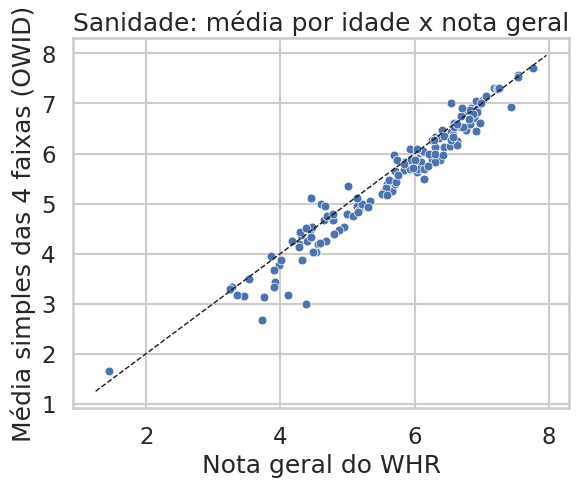

In [5]:
# 5.3 Planilha da Figura 2.1 do WHR: nota geral por país (verificação de sanidade)
import io, requests
from lab_helpers import to_iso3

WHR_XLSX = "https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx"
WHR_CSV = "Happiness-Around-the-World-Data.csv"   # plano B: ranking fornecido em aula
whr = None
try:
    # o servidor recusa (403) pedidos sem "User-Agent", então baixamos com requests
    resp = requests.get(WHR_XLSX, headers={"User-Agent": "Mozilla/5.0 (PUCSP lab)"}, timeout=60)
    resp.raise_for_status()
    whr = pd.read_excel(io.BytesIO(resp.content))
    print(whr.columns.tolist())
    display(whr.head())
    last_year = whr["Year"].max()
    whr = (whr[whr["Year"] == last_year]
             .rename(columns={"Country name": "name", "Life evaluation (3-year average)": "whr_score"}))
    print("usando a janela de 3 anos terminada em", last_year)
except Exception as err:
    print("planilha indisponível:", type(err).__name__, err)
    if os.path.exists(WHR_CSV):
        print("-> usando", WHR_CSV)
        whr = pd.read_csv(WHR_CSV).rename(columns={"Country": "name", "Life Evaluation Score": "whr_score"})
    else:
        print(f"-> {WHR_CSV} também não encontrado; verificação de sanidade pulada (não afeta os modelos)")

if whr is not None:
    # Tarefa 2.1: esta fonte só tem NOMES -> converter para ISO3 e ler os nomes sem correspondência
    # Regiões não soberanas colidem com o país "pai" (Somaliland -> SOM, North Cyprus -> CYP): removemos.
    REGIONS = ["Somaliland region", "Somaliland", "North Cyprus", "Northern Cyprus"]
    whr = whr[~whr["name"].isin(REGIONS)].dropna(subset=["whr_score"]).copy()
    whr["iso3"] = to_iso3(whr["name"])
    manual_fix = {"The Republic of the Congo": "COG"}
    whr["iso3"] = whr["iso3"].fillna(whr["name"].map(manual_fix))
    whr = whr.dropna(subset=["iso3"])
    assert not whr["iso3"].duplicated().any(), "dois nomes viraram o mesmo ISO3"

    check = (age.groupby("iso3")["ladder_mean"].mean().rename("age_avg").reset_index()
                .merge(whr[["iso3", "whr_score"]], on="iso3", how="inner"))
    print(f"{len(check)} países em comum | correlação = {check['age_avg'].corr(check['whr_score']):.3f}"
          f" | diferença média absoluta = {(check['age_avg'] - check['whr_score']).abs().mean():.3f}")
    ax = sns.scatterplot(data=check, x="whr_score", y="age_avg", s=40)
    lims = [check[["whr_score", "age_avg"]].min().min() - .2, check[["whr_score", "age_avg"]].max().max() + .2]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set(xlabel="Nota geral do WHR", ylabel="Média simples das 4 faixas (OWID)",
           title="Sanidade: média por idade x nota geral")
    plt.show()

As duas medidas quase coincidem (correlação perto de 1), mas não são idênticas: a média simples das quatro faixas não pondera pelo tamanho de cada faixa na população e as janelas de anos podem diferir. Serve como checagem de que os dados por idade estão coerentes; **a nota geral não entra como atributo** nos modelos, porque ela é quase a própria variável-alvo.

**Plano B se estiverem offline ou o download falhar.** O `lab_helpers.py` sabe **simular** dados por idade. A simulação usa o PIB per capita real, uma curva em U plantada na idade e ruído, e marca todas as linhas com `synthetic=True`. Use apenas para testar o pipeline, e **nunca reporte esses números como descobertas sobre o mundo real**.

```python
from lab_helpers import build_country_table, make_synthetic_age_data
age = make_synthetic_age_data(build_country_table())
```

## 6. Parte 2: enriquecer com PIB, população e tamanho do país

A felicidade varia muito mais **entre países** do que **entre faixas etárias**, então vocês precisam de controles no nível do país antes que o efeito da idade signifique alguma coisa. Vocês vão buscar três indicadores do Banco Mundial pela API pública e juntá-los pelo código **ISO3**, e não pelo nome.

| Atributo | Indicador do Banco Mundial | Por que transformar |
| --- | --- | --- |
| PIB per capita, PPC (dólares internacionais constantes) | `NY.GDP.PCAP.PP.KD` | A renda tem retornos decrescentes, então use `log` |
| População | `SP.POP.TOTL` | Varia em 5 ordens de grandeza (Islândia a Índia), então use `log` |
| Área terrestre (km²) | `AG.LND.TOTL.K2` | Mesma assimetria da população, então use `log` |

`lab_helpers.build_country_table()` chama a API, guarda o último valor não faltante de 2019 a 2023 para cada indicador e descarta os agregados regionais (como "World" e "Arab World") que a API mistura com os países. **Leiam o código antes de rodar**: a resposta é uma lista de dois elementos, com os metadados primeiro e os registros depois.

**Tarefa 2.1.** Confiram as chaves de país. O arquivo do OWID já traz códigos ISO3 na coluna `iso3`, então os dados por idade não precisam de comparação de nomes. Usem `to_iso3` só para fontes que trazem apenas o nome do país (a planilha do WHR, por exemplo), e leiam a lista de nomes sem correspondência que ela imprime.

**Tarefa 2.2.** Juntem a tabela de idade com a tabela de países usando `validate="many_to_one"`. Depois imprimam os países que perderam dados porque o Banco Mundial não tem valor para eles.

**Tarefa 2.3.** Criem os atributos: `age_mid` a partir do dicionário `AGE_MID` do `lab_helpers.py`, `age_sq`, `log_gdp_pc`, `log_pop`, `log_area` e `pop_density = pop / area_km2`.

In [6]:
from lab_helpers import AGE_MID, build_country_table, load_owid_age, to_iso3

age = load_owid_age()
assert (age.groupby("iso3").size() == 4).all(), "algum código ISO3 tem mais ou menos de 4 linhas de idade"

# Usa country_table.csv (foto de 2026-09-21) se existir; refresh=True busca de novo na API
countries = build_country_table()
print("países na tabela do Banco Mundial:", len(countries))

df = age.merge(countries, on="iso3", how="left", validate="many_to_one")

# Tarefa 2.2: auditoria do join
lost = df[df[["gdp_pc", "pop", "area_km2"]].isna().any(axis=1)].drop_duplicates("iso3")
print("Países com dado faltando no Banco Mundial:")
display(lost[["country", "iso3", "gdp_pc", "pop", "area_km2"]])

países na tabela do Banco Mundial: 217
Países com dado faltando no Banco Mundial:


,country,iso3,gdp_pc,pop,area_km2
516,Taiwan,TWN,NaN,NaN,NaN
544,Venezuela,VEN,NaN,28300854.0,882050.0
552,Kosovo,XKX,14240.203032,1682668.0,NaN
556,Yemen,YEM,NaN,39390799.0,527970.0


**Decisões sobre os países perdidos** (auditoria do *join*):

- **Kosovo:** o OWID usa o código próprio `OWID_KOS`; o `lab_helpers` o traduz para `XKX`, que é o código do Banco Mundial. O Banco Mundial não publica a área terrestre de Kosovo, então **corrigimos manualmente** com 10.887 km² (área oficial do país), e registramos isso aqui.
- **Taiwan:** não aparece nos dados do Banco Mundial. **Descartado.**
- **Venezuela e Iêmen:** o Banco Mundial não tem PIB per capita PPC em 2019-2023. **Descartados**, porque imputar o PIB de países em crise seria inventar dado.

In [7]:
KOSOVO_AREA_KM2 = 10_887   # fonte: área oficial de Kosovo; o Banco Mundial não publica AG.LND.TOTL.K2 para XKX
df.loc[df["iso3"].eq("XKX") & df["area_km2"].isna(), "area_km2"] = KOSOVO_AREA_KM2

dropped = df[df[["gdp_pc", "pop", "area_km2"]].isna().any(axis=1)]["country"].unique()
print("descartados:", list(dropped))
df = df.dropna(subset=["gdp_pc", "pop", "area_km2"]).reset_index(drop=True)

# Tarefa 2.3: atributos
df["age_mid"] = df["age_group"].astype(str).map(AGE_MID).astype(float)
df["age_sq"] = df["age_mid"] ** 2
df["log_gdp_pc"] = np.log(df["gdp_pc"])
df["log_pop"] = np.log(df["pop"])
df["log_area"] = np.log(df["area_km2"])
df["pop_density"] = df["pop"] / df["area_km2"]

print(f"{df['iso3'].nunique()} países mantidos, {len(df)} linhas")
assert (df.groupby("iso3").size() == 4).all()
display(df.head(8))
display(df[["ladder_mean", "gdp_pc", "pop", "area_km2", "log_gdp_pc", "log_pop", "log_area"]].describe().round(2))

descartados: ['Taiwan', 'Venezuela', 'Yemen']
140 países mantidos, 560 linhas


,country,iso3,year,age_group,ladder_mean,window,gdp_pc,pop,area_km2,age_mid,age_sq,log_gdp_pc,log_pop,log_area,pop_density
0,Afghanistan,AFG,2023,<30,1.827,2021-2023,1983.812620,41454761.0,652230.0,22.0,484.0,7.592776,17.540113,13.388153,63.558501
1,Afghanistan,AFG,2023,30-44,1.617,2021-2023,1983.812620,41454761.0,652230.0,37.0,1369.0,7.592776,17.540113,13.388153,63.558501
2,Afghanistan,AFG,2023,45-59,1.681,2021-2023,1983.812620,41454761.0,652230.0,52.0,2704.0,7.592776,17.540113,13.388153,63.558501
3,Afghanistan,AFG,2023,60+,1.456,2021-2023,1983.812620,41454761.0,652230.0,70.0,4900.0,7.592776,17.540113,13.388153,63.558501
4,Albania,ALB,2023,<30,6.358,2021-2023,20501.647073,2411658.0,27400.0,22.0,484.0,9.928261,14.695825,10.218298,88.016715
5,Albania,ALB,2023,30-44,5.289,2021-2023,20501.647073,2411658.0,27400.0,37.0,1369.0,9.928261,14.695825,10.218298,88.016715
6,Albania,ALB,2023,45-59,4.704,2021-2023,20501.647073,2411658.0,27400.0,52.0,2704.0,9.928261,14.695825,10.218298,88.016715
7,Albania,ALB,2023,60+,4.643,2021-2023,20501.647073,2411658.0,27400.0,70.0,4900.0,9.928261,14.695825,10.218298,88.016715


,ladder_mean,gdp_pc,pop,area_km2,log_gdp_pc,log_pop,log_area
count,560.00,560.00,5.600000e+02,560.00,560.00,560.00,560.00
mean,5.49,27476.23,5.492350e+07,858901.20,9.70,16.48,12.08
std,1.25,26294.81,1.740356e+08,2111002.57,1.13,1.55,2.00
min,1.46,1512.67,3.856630e+05,320.00,7.32,12.86,5.77
25%,4.60,6665.41,5.283654e+06,60385.00,8.80,15.48,11.01
50%,5.65,17725.72,1.199019e+07,228806.50,9.78,16.30,12.34
75%,6.49,42244.39,4.040051e+07,675210.41,10.65,17.51,13.42
max,7.92,130296.84,1.438070e+09,16376870.00,11.78,21.09,16.61


Por que o log: o PIB per capita vai de cerca de US$ 1 mil a US$ 130 mil, a população de centenas de milhares a 1,4 bilhão e a área de alguns km² a 16 milhões de km². Em escala linear poucos países gigantes dominariam o ajuste; com log, cada **multiplicação** por 10 vira um passo constante, o que também combina com a ideia de retornos decrescentes da renda. Os histogramas abaixo mostram a diferença.

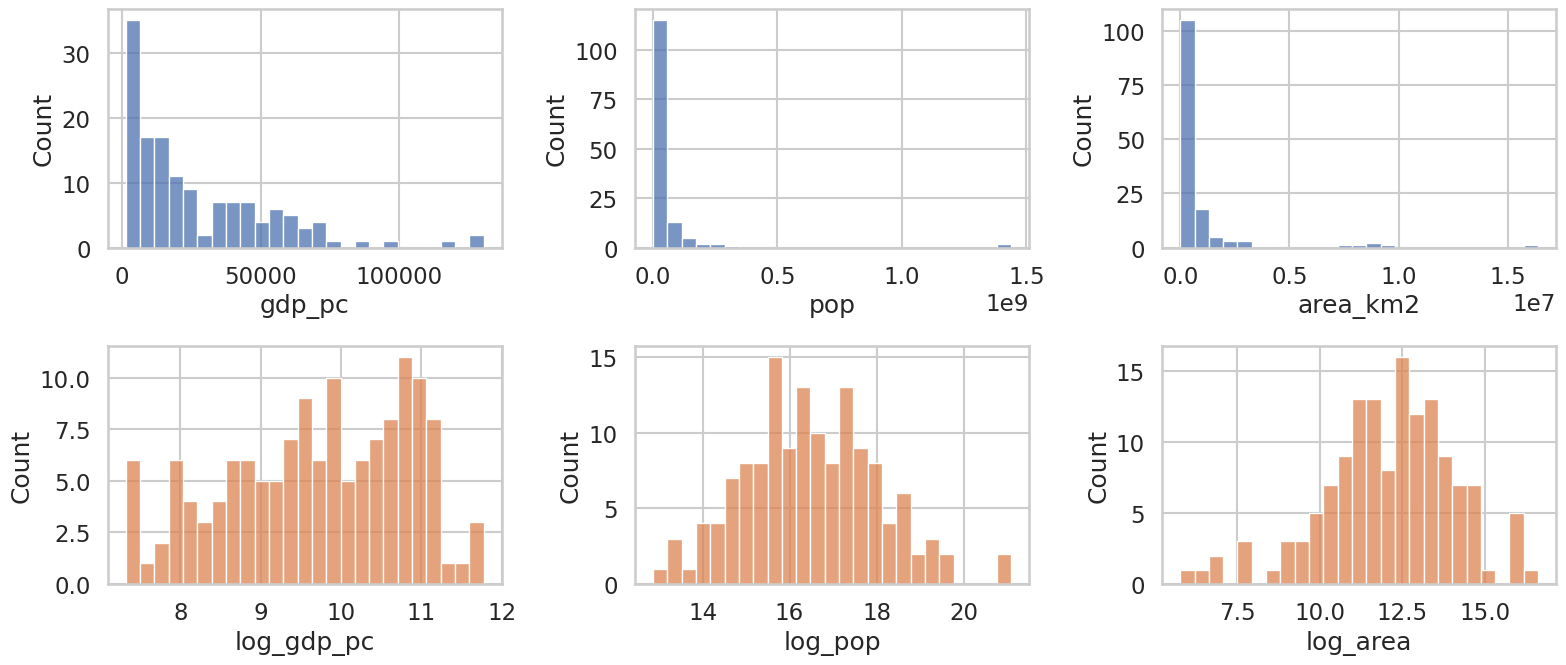

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for j, (raw_col, log_col) in enumerate([("gdp_pc", "log_gdp_pc"), ("pop", "log_pop"), ("area_km2", "log_area")]):
    one = df.drop_duplicates("iso3")
    sns.histplot(one[raw_col], ax=axes[0, j], bins=25)
    sns.histplot(one[log_col], ax=axes[1, j], bins=25, color="C1")
plt.tight_layout()
plt.show()

**Armadilhas para observar:**

- **Códigos que o Banco Mundial não usa.** Alguns territórios podem ter um código que o Banco Mundial não tem. Taiwan, em geral, também não aparece nos dados do Banco Mundial. Olhem os países perdidos na Tarefa 2.2 e decidam, para cada um, se vale corrigir ou descartar.
- **Fontes só com nomes.** Se vocês acrescentarem dados sem coluna ISO3, dois nomes podem virar o mesmo código ("Somaliland region" vira o mesmo código da Somália). Mantenham a asserção acima para que uma colisão dessas falhe de forma visível.
- **Valores defasados.** O PIB do ano mais recente costuma vir em branco, e por isso o auxiliar pega o último valor disponível em uma janela. Informem a janela no relatório.
- `AGE_MID["60+"] = 70` é uma suposição, já que a faixa é aberta. Registrem isso e testem 65 como checagem de robustez.

### Acrescente seus próprios dados (escolha livre)

Os três indicadores do Banco Mundial são um ponto de partida, **não um limite**. Vocês podem acrescentar **qualquer informação** que julguem útil para explicar a felicidade entre idades e países, e não precisam pedir permissão. Algumas ideias:

- Demografia: expectativa de vida, idade mediana, proporção de pessoas acima de 60 anos, urbanização.
- Economia e sociedade: desemprego, desigualdade de renda (Gini), educação, gastos com saúde, uso de internet.
- Os fatores explicativos brutos da planilha do WHR, como apoio social, liberdade, generosidade e percepção de corrupção.
- Geografia e cultura: região, latitude, clima, religião ou idioma predominante.
- Qualquer outro indicador do Banco Mundial (troquem o código em `WB_INDICATORS`) ou qualquer outro conjunto de dados do Our World in Data.

As regras são sobre honestidade, não sobre permissão. **Juntem por ISO3, citem a fonte e a data do download, apliquem logaritmo em variáveis assimétricas** e coloquem as novas colunas em `FEATURES`, para que as Partes 3 e 4 as usem. Depois **mostrem o que mudou**: comparem o RMSE em validação cruzada com e sem as novas colunas na Parte 3, e o AUC na Parte 4. Dois cuidados. **Não usem a nota geral do WHR como atributo**, porque ela é quase a própria variável-alvo. E tratem com cautela as colunas de contribuição ("explained by") da planilha, porque elas são saídas da regressão do próprio relatório.

In [9]:
# (Opcional) Dados extras: não acrescentamos nenhum nesta versão.
# Para acrescentar, por exemplo, expectativa de vida do Banco Mundial:
# from lab_helpers import fetch_wb
# extra = fetch_wb("SP.DYN.LE00.IN").rename("life_exp").reset_index()
# df = df.merge(extra, on="iso3", how="left")
# Documentar: fonte, data do download, anos e chave de junção (iso3).

## 7. Parte 3: regressão linear e visualização com Seaborn

O objetivo é mostrar, com gráficos e números de validação cruzada, **se a idade precisa de uma curva em vez de uma reta**, e quanto do quadro é explicado pela riqueza em vez de pela idade. Vocês vão ajustar três modelos aninhados com `sklearn.linear_model.LinearRegression`:

$$\text{M1: } \hat y = \beta_0 + \beta_1\,\text{idade} \qquad$$

$$\text{M2: } \hat y = \beta_0 + \beta_1\,\text{idade} + \beta_2\,\text{idade}^2$$

$$\text{M3: } \hat y = \text{M2} + \beta_3 \ln(\text{PIB pc}) + \beta_4 \ln(\text{pop}) + \beta_5 \ln(\text{área})$$

Em M2 e M3, a curva ajustada vira em **idade = −β₁ / (2β₂)**. Essa é a estimativa de vocês para a idade em que a felicidade atinge o mínimo, e dá para compará-la com os 40 e poucos ou início dos 50 anos citados no artigo do WEF.

**Tarefa 3.1. Reta ou curva.** Desenhem lado a lado dois gráficos de dispersão de `ladder_mean` contra `age_mid`, um com `order=1` e outro com `order=2`. O Seaborn ajusta e desenha o polinômio para vocês.

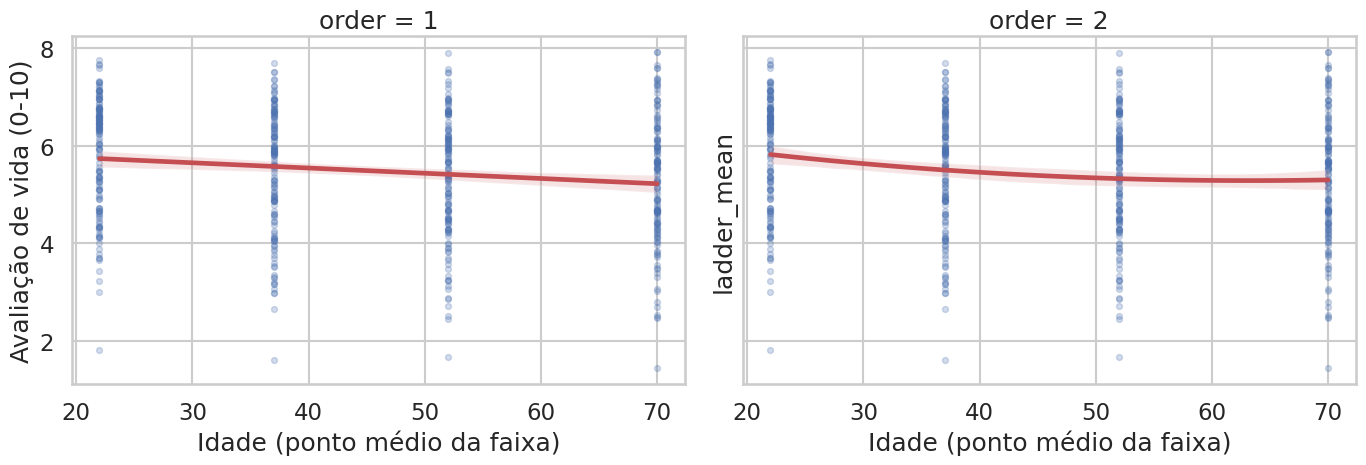

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, order in zip(axes, [1, 2]):
    sns.regplot(data=df, x="age_mid", y="ladder_mean", order=order, ax=ax,
                scatter_kws={"alpha": 0.25, "s": 18}, line_kws={"color": "C3"})
    ax.set_title(f"order = {order}")
    ax.set_xlabel("Idade (ponto médio da faixa)")
axes[0].set_ylabel("Avaliação de vida (0-10)")
plt.tight_layout()
plt.savefig("figures/3_1_reta_vs_curva.png", dpi=120, bbox_inches="tight")
plt.show()

Com os dados brutos, a reta e a parábola quase se sobrepõem: a nuvem é dominada pela distância vertical entre países (de ≈1,5 no Afeganistão a ≈7,9 na Finlândia), e a diferença entre faixas etárias é pequena perto disso.

**Tarefa 3.2. O perfil da idade dentro dos países.** Países ricos e pobres ficam em alturas muito diferentes, o que pode esconder o padrão da idade. Subtraiam a média de cada país e plotem o desvio por faixa de renda com `sns.lmplot(..., col="income_tier", order=2)`. Criem as faixas com `pd.qcut(df["gdp_pc"], 3, labels=[...])`.

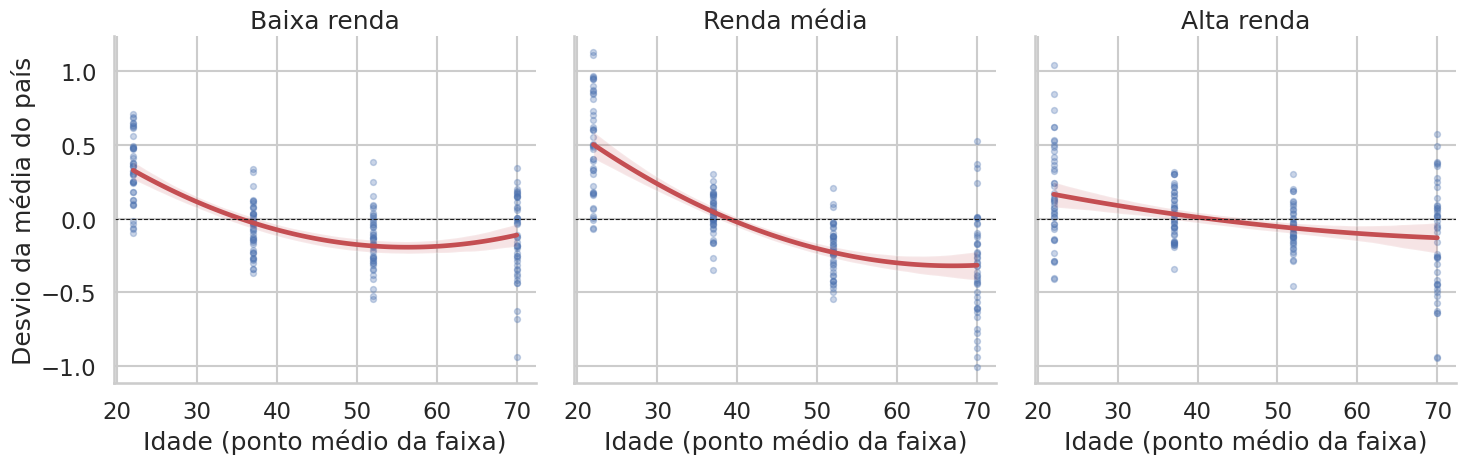

age_group,<30,30-44,45-59,60+
income_tier,,,,
Baixa renda,0.341,-0.069,-0.149,-0.123
Renda média,0.506,0.032,-0.218,-0.320
Alta renda,0.167,0.023,-0.058,-0.132


In [11]:
df["ladder_dev"] = df["ladder_mean"] - df.groupby("iso3")["ladder_mean"].transform("mean")
df["income_tier"] = pd.qcut(df["gdp_pc"], 3, labels=["Baixa renda", "Renda média", "Alta renda"])

g = sns.lmplot(data=df, x="age_mid", y="ladder_dev", col="income_tier", order=2,
               scatter_kws={"alpha": 0.3, "s": 18}, line_kws={"color": "C3"}, height=5)
g.set_axis_labels("Idade (ponto médio da faixa)", "Desvio da média do país")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.axhline(0, color="k", lw=0.8, ls="--")
plt.savefig("figures/3_2_perfil_dentro_paises.png", dpi=120, bbox_inches="tight")
plt.show()

profile = df.pivot_table(index="income_tier", columns="age_group", values="ladder_dev", observed=True).round(3)
display(profile)

Dentro dos países o sinal aparece: nos três grupos de renda, os **jovens (<30)** estão bem acima da média do próprio país, e a felicidade **cai** até a meia-idade. A diferença está no final: em renda baixa a curva se achata e sobe um pouco depois dos 45-59 (um U raso), enquanto em renda média ela continua caindo até 60+. Em renda alta a queda é bem mais suave (de +0,17 para −0,13), porque ali convivem padrões opostos: EUA, Canadá e países nórdicos sobem com a idade, enquanto Lituânia e Eslovênia caem. Para ver quem foge do padrão, a figura abaixo mostra alguns países citados no WHR 2024.

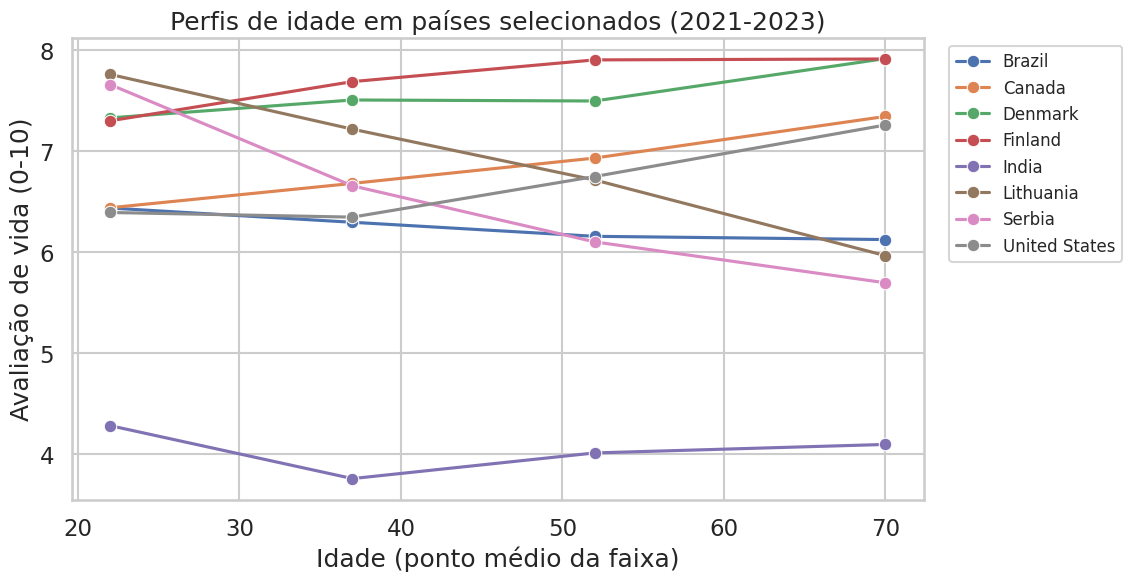

In [12]:
sel = ["United States", "Canada", "Finland", "Denmark", "Brazil", "Lithuania", "Serbia", "India"]
fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(data=df[df["country"].isin(sel)], x="age_mid", y="ladder_mean", hue="country", marker="o", ax=ax)
ax.set(xlabel="Idade (ponto médio da faixa)", ylabel="Avaliação de vida (0-10)",
       title="Perfis de idade em países selecionados (2021-2023)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=12)
plt.savefig("figures/3_2b_paises_selecionados.png", dpi=120, bbox_inches="tight")
plt.show()

**Tarefa 3.3. Comparem três modelos em países não vistos.** Uma divisão aleatória de linhas colocaria as outras faixas etárias do mesmo país no treino, então dividam **por país** com `GroupKFold`. Reportem R² e RMSE em validação cruzada para M1, M2 e M3, e depois repitam M1 e M2 com `ladder_dev` como alvo.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

def cv_scores(features, target="ladder_mean", k=5, data=None):
    # Validação cruzada agrupada por país: um país inteiro fica no treino OU no teste.
    data = df if data is None else data
    pred = cross_val_predict(LinearRegression(), data[features], data[target],
                             groups=data["iso3"], cv=GroupKFold(n_splits=k))
    return r2_score(data[target], pred), mean_squared_error(data[target], pred) ** 0.5, pred

models = {
    "M1 idade": ["age_mid"],
    "M2 idade + idade²": ["age_mid", "age_sq"],
    "M3 M2 + log PIB, log pop, log área": ["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"],
}
rows, cv_pred = [], {}
for name, feats in models.items():
    r2, rmse, pred = cv_scores(feats)
    cv_pred[name] = pred
    rows.append({"modelo": name, "alvo": "ladder_mean", "R2_cv": r2, "RMSE_cv": rmse})
for name in ["M1 idade", "M2 idade + idade²"]:
    r2, rmse, _ = cv_scores(models[name], target="ladder_dev")
    rows.append({"modelo": name, "alvo": "ladder_dev (dentro do país)", "R2_cv": r2, "RMSE_cv": rmse})
results = pd.DataFrame(rows).round(3)
display(results)

,modelo,alvo,R2_cv,RMSE_cv
0,M1 idade,ladder_mean,0.019,1.238
1,M2 idade + idade²,ladder_mean,0.023,1.235
2,"M3 M2 + log PIB, log pop, log área",ladder_mean,0.625,0.765
3,M1 idade,ladder_dev (dentro do país),0.320,0.276
4,M2 idade + idade²,ladder_dev (dentro do país),0.377,0.264


Leitura da tabela: com `ladder_mean` como alvo, a idade sozinha (M1, M2) tem R² perto de zero, porque ela não diz nada sobre **em qual país** a pessoa vive. Quando entram os controles de país (M3), o R² sobe para cerca de 0,6 e o RMSE cai de ≈1,24 para ≈0,76 ponto. Com `ladder_dev` (a variação **dentro** do país), a idade passa a explicar em torno de 30-40%, e o termo quadrático melhora o ajuste em relação à reta.

**Checagem de robustez: `60+` = 65 em vez de 70.**

In [14]:
from lab_helpers import AGE_MID
def vertex(data, target="ladder_dev"):
    m = LinearRegression().fit(data[["age_mid", "age_sq"]], data[target])
    b1, b2 = m.coef_
    return -b1 / (2 * b2), b2

alt = df.copy()
alt["age_mid"] = alt["age_group"].astype(str).map({**AGE_MID, "60+": 65}).astype(float)
alt["age_sq"] = alt["age_mid"] ** 2
for label, d in [("60+ = 70", df), ("60+ = 65", alt)]:
    v, b2 = vertex(d)
    r2, rmse, _ = cv_scores(["age_mid", "age_sq"], target="ladder_dev", data=d)
    print(f"{label}: mínimo em {v:.1f} anos (b2 = {b2:.2e}) | R2_cv dentro do país = {r2:.3f}")

60+ = 70: mínimo em 63.3 anos (b2 = 3.13e-04) | R2_cv dentro do país = 0.377
60+ = 65: mínimo em 61.5 anos (b2 = 3.37e-04) | R2_cv dentro do país = 0.378


**Tarefa 3.4. Riqueza e resíduos.** Ajustem M3 com todas as linhas e imprimam os coeficientes e a idade do mínimo. Depois desenhem a riqueza contra a felicidade (`x="log_gdp_pc"`, colorido por `age_group`), além de previsto contra real e um gráfico de resíduos usando as previsões da validação cruzada. Identifiquem os três países com os maiores resíduos e sugiram o que o modelo não está capturando.

intercepto: -1.46


,coeficiente
age_mid,-0.03959
age_sq,0.00031
log_gdp_pc,0.86945
log_pop,-0.09103
log_area,0.08873


idade do mínimo (M3) = -b1/(2*b2) = 63.3 anos
efeito de dobrar o PIB per capita: +0.60 ponto
efeito da idade de 22 para 70 anos: -0.52 ponto


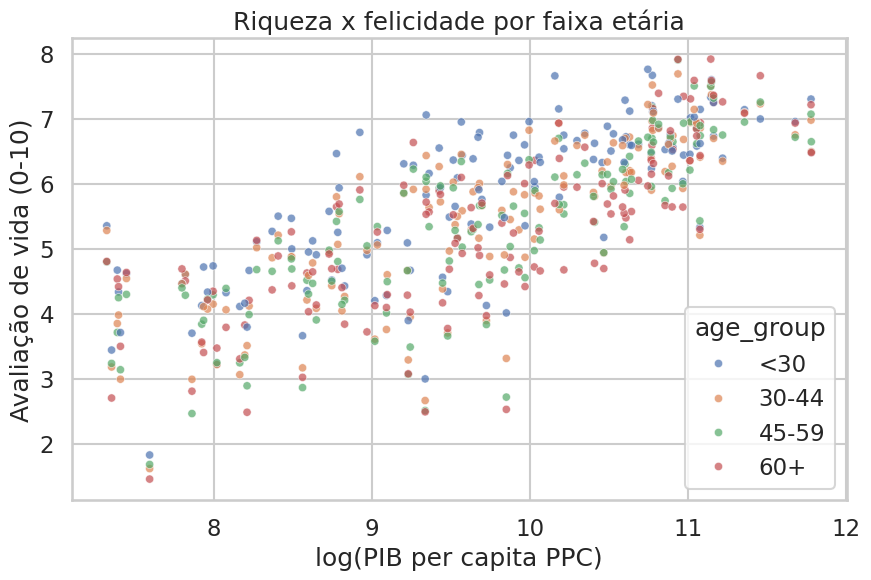

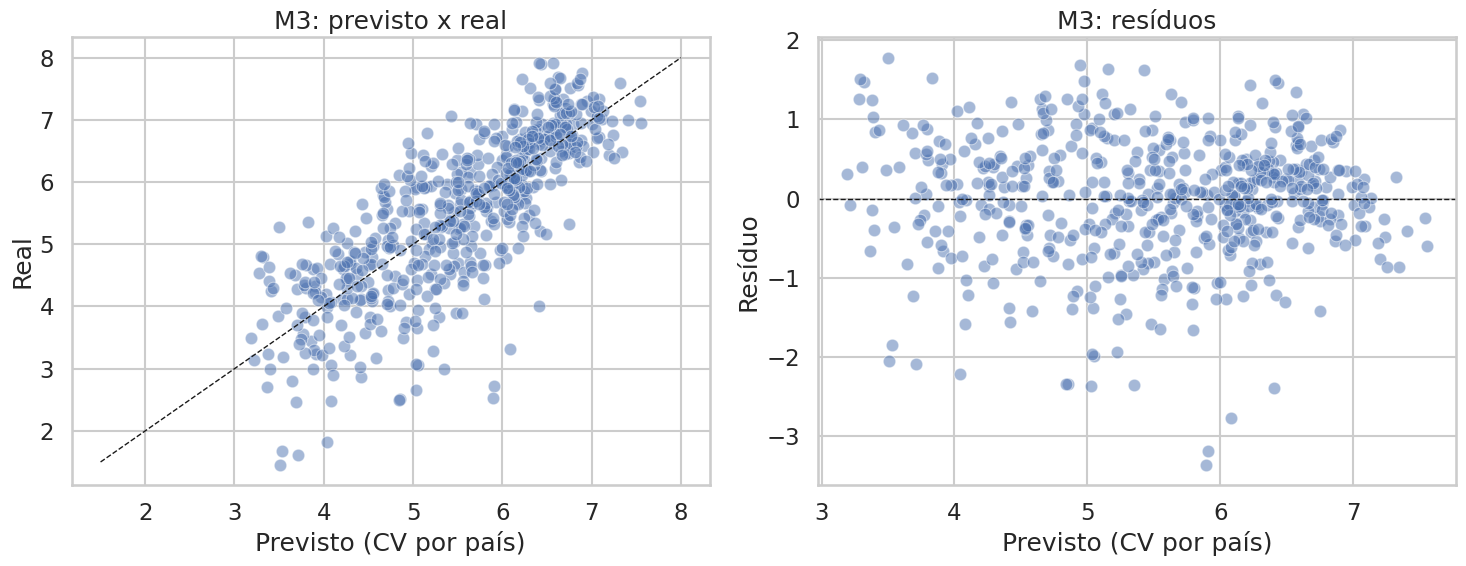

Maiores resíduos negativos (modelo superestima):


,resid_m3_cv
country,
Botswana,-2.93
Lebanon,-2.35
Afghanistan,-2.05


Maiores resíduos positivos (modelo subestima):


,resid_m3_cv
country,
El Salvador,1.23
Nicaragua,1.31
Mozambique,1.57


In [15]:
m3_feats = models["M3 M2 + log PIB, log pop, log área"]
m3 = LinearRegression().fit(df[m3_feats], df["ladder_mean"])
coefs = pd.Series(m3.coef_, index=m3_feats)
print("intercepto:", round(m3.intercept_, 3))
display(coefs.round(5).to_frame("coeficiente"))
b1, b2 = coefs["age_mid"], coefs["age_sq"]
print(f"idade do mínimo (M3) = -b1/(2*b2) = {-b1 / (2 * b2):.1f} anos")
print(f"efeito de dobrar o PIB per capita: {coefs['log_gdp_pc'] * np.log(2):+.2f} ponto")
print(f"efeito da idade de 22 para 70 anos: {(b1*70 + b2*70**2) - (b1*22 + b2*22**2):+.2f} ponto")

# Gráfico 1: riqueza x felicidade
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="log_gdp_pc", y="ladder_mean", hue="age_group", alpha=0.7, s=35, ax=ax)
ax.set(xlabel="log(PIB per capita PPC)", ylabel="Avaliação de vida (0-10)", title="Riqueza x felicidade por faixa etária")
plt.savefig("figures/3_4a_riqueza.png", dpi=120, bbox_inches="tight")
plt.show()

# Gráficos 2 e 3: previsto x real e resíduos (previsões da validação cruzada por país)
df["pred_m3_cv"] = cv_pred["M3 M2 + log PIB, log pop, log área"]
df["resid_m3_cv"] = df["ladder_mean"] - df["pred_m3_cv"]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=df, x="pred_m3_cv", y="ladder_mean", alpha=0.5, ax=axes[0])
axes[0].plot([1.5, 8], [1.5, 8], "k--", lw=1)
axes[0].set(xlabel="Previsto (CV por país)", ylabel="Real", title="M3: previsto x real")
sns.scatterplot(data=df, x="pred_m3_cv", y="resid_m3_cv", alpha=0.5, ax=axes[1])
axes[1].axhline(0, color="k", lw=1, ls="--")
axes[1].set(xlabel="Previsto (CV por país)", ylabel="Resíduo", title="M3: resíduos")
plt.tight_layout()
plt.savefig("figures/3_4b_residuos.png", dpi=120, bbox_inches="tight")
plt.show()

resid_country = df.groupby("country")["resid_m3_cv"].mean().sort_values()
print("Maiores resíduos negativos (modelo superestima):")
display(resid_country.head(3).round(2))
print("Maiores resíduos positivos (modelo subestima):")
display(resid_country.tail(3).round(2))

**O que esperar, e por quê.** As diferenças entre países são grandes perto das diferenças entre idades, então a idade sozinha explica muito pouco da nota bruta, mesmo quando o formato dela é claro dentro dos países. Se o R² de M1 e M2 ficar perto de zero enquanto o gráfico dentro dos países mostra uma curva clara, isso é um **resultado** a explicar no relatório, não um erro.

**Minhas conclusões da Parte 3:**

- **Reta ou curva.** Na nota bruta, M1 e M2 têm R² em validação cruzada perto de zero (≈0,02). Não é erro: a idade não informa o país, e é o país que define a altura da nota. Dentro dos países, a idade explica cerca de 30-40% da variação e o termo quadrático melhora a reta (R² ≈0,32 → ≈0,38), então há curvatura.
- **Onde fica o mínimo.** A parábola ajustada vira por volta dos **63 anos**, e não nos 40-50 do artigo do WEF. Isso acontece porque, no conjunto dos 140 países, o padrão dominante é **queda com a idade**: os jovens (<30) estão ≈0,3 a 0,5 ponto acima da média do próprio país, e a curva só se achata no fim. Com `60+` = 65, o vértice vai para ≈61,5 anos e a interpretação não muda; a conclusão continua sendo "cai e depois se estabiliza", não um U simétrico.
- **Riqueza pesa muito mais que idade.** Em M3, dobrar o PIB per capita soma ≈0,6 ponto, enquanto ir de 22 para 70 anos tira ≈0,5 ponto. Ou seja: a diferença entre um jovem e um idoso do mesmo país equivale a uma diferença de renda próxima de 2 vezes; a distância entre a Finlândia e o Malawi (PIB ≈35 vezes maior) vale mais de 3 pontos. População e área têm coeficientes pequenos.
- **Resíduos.** Os maiores erros negativos são Botsuana, Líbano e Afeganistão, onde a vida é bem pior do que o PIB sugere (crise econômica e política no Líbano, regime Talibã no Afeganistão, desigualdade e desemprego altos em Botsuana). Os maiores positivos são Moçambique, Nicarágua e El Salvador, mais felizes do que a renda prevê (um padrão conhecido na América Latina, ligado a laços familiares e sociais fortes). O modelo não captura apoio social, liberdade, corrupção, conflitos e fatores culturais.

## 8. Parte 4: regressão logística, feliz ou não por idade e país

A regressão linear prevê uma nota; a regressão logística prevê a **probabilidade** de um grupo ser "feliz", o que exige um rótulo sim/não. Vocês vão definir o rótulo, treinar `LogisticRegression` e embrulhar o resultado em uma função que uma pessoa sem experiência em programação consiga usar: dê um país e uma idade, receba uma probabilidade.

$$P(\text{feliz} = 1 \mid x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1\,\text{idade} + \beta_2\,\text{idade}^2 + \beta_3 \ln \text{PIB} + \beta_4 \ln \text{pop} + \beta_5 \ln \text{área})}}$$

**Tarefa 4.1. Definam o rótulo.** Chamem um grupo de feliz quando `ladder_mean` estiver acima da **mediana** de todos os grupos. A mediana dá classes balanceadas, então a acurácia faz sentido. Imprimam o limiar e a proporção de linhas felizes, e escrevam uma frase sobre como as conclusões mudariam com um limiar fixo, como 6,0.

**Tarefa 4.2. Treinem e avaliem em países não vistos.** Usem `GroupShuffleSplit` para que um país fique inteiro no treino ou inteiro no teste. Padronizem os atributos numéricos dentro de um `Pipeline`, para que a escala seja aprendida só com as linhas de treino. Reportem acurácia, AUC-ROC e a matriz de confusão.

limiar: 5.65 | proporção de felizes: 0.5
com limiar fixo 6,0 a proporção seria: 0.39
países: 105 treino / 35 teste
acurácia = 0.843 | AUC-ROC = 0.937


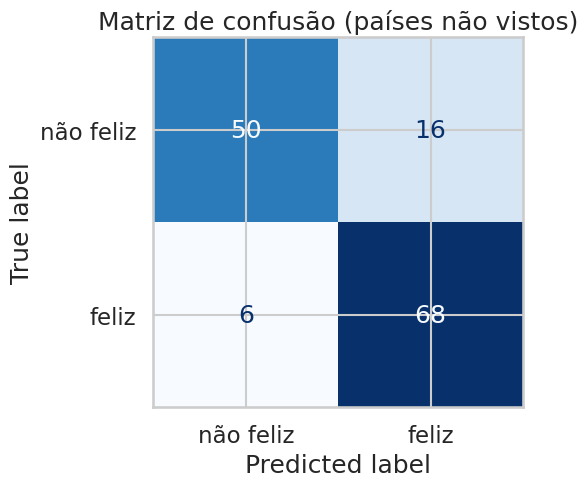

,coef (padronizado)
age_mid,-0.499
age_sq,0.000
log_gdp_pc,2.454
log_pop,-0.187
log_area,0.266


In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

THRESHOLD = df["ladder_mean"].median()
df["happy"] = (df["ladder_mean"] > THRESHOLD).astype(int)
print("limiar:", round(THRESHOLD, 2), "| proporção de felizes:", df["happy"].mean().round(2))
print("com limiar fixo 6,0 a proporção seria:", (df["ladder_mean"] > 6.0).mean().round(2))

FEATURES = ["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"]   # acrescente suas colunas extras aqui

def make_classifier():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, df["happy"], groups=df["iso3"]))
train, test = df.iloc[train_idx], df.iloc[test_idx]
assert set(train["iso3"]).isdisjoint(test["iso3"]), "vazamento: país no treino e no teste"

clf = make_classifier().fit(train[FEATURES], train["happy"])
p_test = clf.predict_proba(test[FEATURES])[:, 1]
y_hat = (p_test > 0.5).astype(int)
print(f"países: {train['iso3'].nunique()} treino / {test['iso3'].nunique()} teste")
print(f"acurácia = {accuracy_score(test['happy'], y_hat):.3f} | AUC-ROC = {roc_auc_score(test['happy'], p_test):.3f}")
cm = confusion_matrix(test["happy"], y_hat)
ConfusionMatrixDisplay(cm, display_labels=["não feliz", "feliz"]).plot(cmap="Blues", colorbar=False)
plt.title("Matriz de confusão (países não vistos)")
plt.show()
display(pd.Series(clf[-1].coef_[0], index=FEATURES).round(3).to_frame("coef (padronizado)"))

**Sobre o limiar.** A mediana (≈5,65) divide as linhas ao meio, então a acurácia de um "chute" é 50% e fica fácil interpretar. Com um limiar fixo de 6,0 só ≈39% das linhas seriam "felizes": as classes ficam desbalanceadas, a acurácia passa a premiar quem prevê "não feliz" e, na prática, o rótulo vira quase um sinônimo de "país rico".

**Tarefa 4.3. Divisão aleatória versus divisão por país.** Repitam a 4.2 com um `train_test_split` aleatório comum. **Antes de rodar, prevejam** se a pontuação vai subir ou descer e por quê. Depois rodem as duas divisões com 20 sementes aleatórias diferentes e comparem as distribuições do AUC. Façam a mesma comparação com um `RandomForestClassifier` e expliquem o que viram.

**Tarefa 4.4. A função.** Implementem `check_happiness(country, age)` seguindo este contrato:

| Item | Requisito |
| --- | --- |
| Entrada | Nome de um país (qualquer grafia que o `to_iso3` entenda) e uma idade em anos |
| Busca | Encontra `log_gdp_pc`, `log_pop` e `log_area` do país na tabela combinada |
| Saída | Um dicionário com `country`, `age`, `p_happy` (arredondado para 3 casas) e `predicted` (`"happy"` se `p_happy` > 0,5, senão `"not happy"`) |
| Erros | Levanta `ValueError` com mensagem legível se o país for desconhecido ou não tiver dados do Banco Mundial |
| Modelo | Treinado uma vez com todas as linhas, **fora** da função, e passado como argumento padrão |

**Previsão antes de rodar (Tarefa 4.3):** a divisão aleatória deve dar AUC **maior**, porque as outras três faixas etárias do mesmo país caem no treino; como elas têm PIB, população e área idênticos e notas parecidas, o modelo "reconhece" o país em vez de generalizar. O efeito deve ser bem mais forte no Random Forest, que consegue memorizar combinações exatas de atributos, do que na regressão logística, que só aprende uma fronteira suave.

mean    std    min    max
modelo        divisão                              
Logística     aleatória  0.925  0.022  0.879  0.948
              por país   0.912  0.031  0.834  0.951
Random Forest aleatória  0.965  0.012  0.948  0.991
              por país   0.897  0.035  0.808  0.938

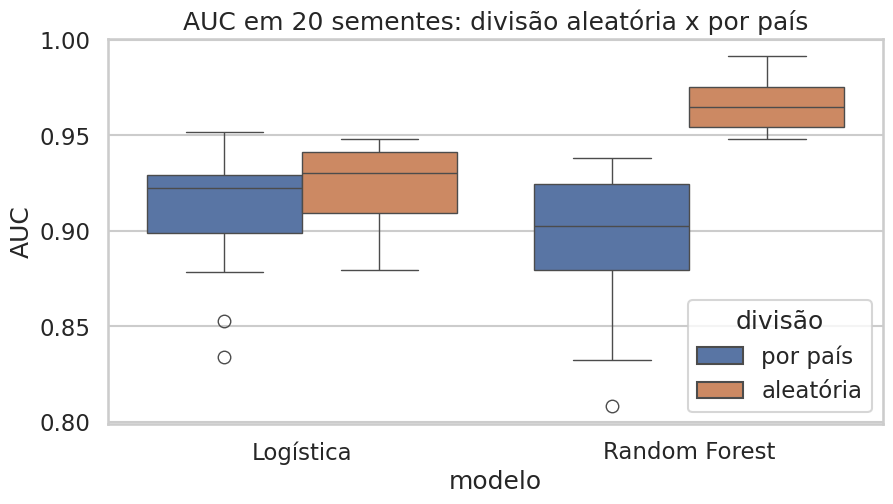

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

def make_rf(seed):
    return RandomForestClassifier(n_estimators=300, min_samples_leaf=1, random_state=seed)

records = []
for seed in range(20):
    # divisão por país
    tr_i, te_i = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
                      .split(df, groups=df["iso3"]))
    # divisão aleatória de linhas
    tr_r, te_r = train_test_split(np.arange(len(df)), test_size=0.25, random_state=seed, stratify=df["happy"])
    for split, (tr, te) in {"por país": (tr_i, te_i), "aleatória": (tr_r, te_r)}.items():
        for model_name, model in [("Logística", make_classifier()), ("Random Forest", make_rf(seed))]:
            model.fit(df.iloc[tr][FEATURES], df.iloc[tr]["happy"])
            p = model.predict_proba(df.iloc[te][FEATURES])[:, 1]
            records.append({"seed": seed, "divisão": split, "modelo": model_name,
                            "AUC": roc_auc_score(df.iloc[te]["happy"], p)})
auc = pd.DataFrame(records)
display(auc.groupby(["modelo", "divisão"])["AUC"].agg(["mean", "std", "min", "max"]).round(3))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=auc, x="modelo", y="AUC", hue="divisão", ax=ax)
ax.set_title("AUC em 20 sementes: divisão aleatória x por país")
plt.savefig("figures/4_3_auc_divisoes.png", dpi=120, bbox_inches="tight")
plt.show()

**O que vimos.** Na regressão logística as duas divisões dão AUC parecidos (≈0,93 x ≈0,91): o modelo é simples demais para memorizar países. No Random Forest a divisão aleatória infla o AUC (≈0,97 em média) e a divisão por país derruba o número para ≈0,90, com variância maior; por país, o Random Forest fica até **abaixo** da logística (≈0,91). A diferença entre as duas colunas do Random Forest é justamente o **vazamento**: medir em linhas de países que o modelo já viu superestima quanto ele sabe sobre países novos.

In [18]:
final_clf = make_classifier().fit(df[FEATURES], df["happy"])
country_lookup = (df.drop_duplicates("iso3")
                    .set_index("iso3")[["country", "log_gdp_pc", "log_pop", "log_area"]])

def check_happiness(country: str, age: float, model=final_clf) -> dict:
    """Retorna P(feliz) e a classe prevista para um país em uma determinada idade.

    Exemplo: check_happiness("Brazil", 30)
    """
    iso = to_iso3(pd.Series([country]), verbose=False).iloc[0]
    if pd.isna(iso):
        raise ValueError(f"País desconhecido: {country!r}. Tente o nome em inglês, ex.: 'Brazil'.")
    if iso not in country_lookup.index:
        raise ValueError(f"{country!r} ({iso}) não tem dados de felicidade por idade ou do Banco Mundial.")
    info = country_lookup.loc[iso]
    row = pd.DataFrame([{"age_mid": float(age), "age_sq": float(age) ** 2,
                         "log_gdp_pc": info["log_gdp_pc"], "log_pop": info["log_pop"],
                         "log_area": info["log_area"]}])[FEATURES]
    p = float(model.predict_proba(row)[0, 1])
    return {"country": info["country"], "age": age, "p_happy": round(p, 3),
            "predicted": "happy" if p > 0.5 else "not happy"}

for c, a in [("Brazil", 25), ("Viet Nam", 60), ("Finland", 40), ("India", 30)]:
    print(check_happiness(c, a))
for bad in ["Atlantis", "Taiwan"]:
    try:
        check_happiness(bad, 30)
    except ValueError as e:
        print("ValueError:", e)

{'country': 'Brazil', 'age': 25, 'p_happy': 0.746, 'predicted': 'happy'}
{'country': 'Vietnam', 'age': 60, 'p_happy': 0.212, 'predicted': 'not happy'}
{'country': 'Finland', 'age': 40, 'p_happy': 0.954, 'predicted': 'happy'}
{'country': 'India', 'age': 30, 'p_happy': 0.219, 'predicted': 'not happy'}
ValueError: País desconhecido: 'Atlantis'. Tente o nome em inglês, ex.: 'Brazil'.
ValueError: 'Taiwan' (TWN) não tem dados de felicidade por idade ou do Banco Mundial.


**Tarefa 4.5. Visualizem.** Chamem a função para idades de 18 a 85 anos, para cinco países de faixas de renda diferentes que vocês escolherem, e desenhem `sns.lineplot(data=curves, x="age", y="p_happy", hue="country")` com uma linha tracejada em 0,5. Olhem as pontas do eixo da idade: os dados só cobrem pontos médios de faixa de 22 a 70, então qualquer comportamento além disso é **extrapolação** de um polinômio quadrático, que pode virar de forma abrupta. Escrevam isso na legenda da figura.

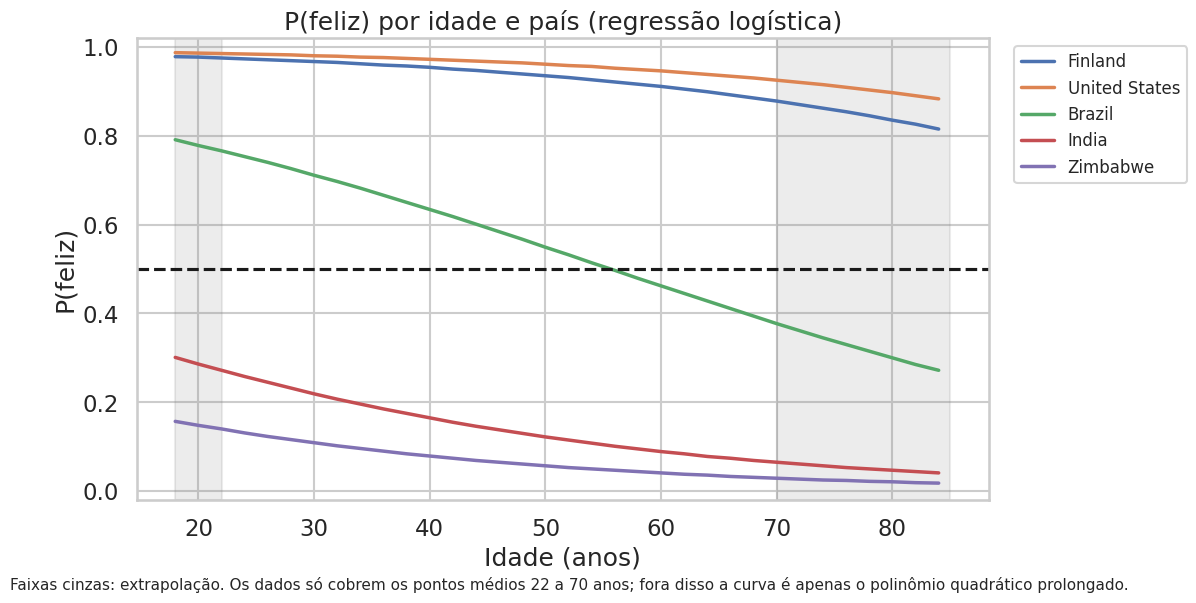

In [19]:
chosen = ["Finland", "United States", "Brazil", "India", "Zimbabwe"]   # renda alta, alta, média, baixa-média, baixa
ages = np.arange(18, 86, 2)

curves = pd.DataFrame([check_happiness(c, a) for c in chosen for a in ages])
fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(data=curves, x="age", y="p_happy", hue="country", ax=ax, lw=2.5)
ax.axhline(0.5, ls="--", color="k")
ax.axvspan(18, 22, color="grey", alpha=0.15)
ax.axvspan(70, 85, color="grey", alpha=0.15)
ax.set(xlabel="Idade (anos)", ylabel="P(feliz)", ylim=(-0.02, 1.02),
       title="P(feliz) por idade e país (regressão logística)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=12)
fig.text(0.01, -0.04, "Faixas cinzas: extrapolação. Os dados só cobrem os pontos médios 22 a 70 anos; "
         "fora disso a curva é apenas o polinômio quadrático prolongado.", fontsize=11)
plt.savefig("figures/4_5_curvas_probabilidade.png", dpi=120, bbox_inches="tight")
plt.show()

Um ponto estrutural para discutir. As quatro linhas de um país compartilham o mesmo PIB, a mesma população e a mesma área, então o modelo só consegue separá-las pela idade. Expliquem o que isso implica sobre o quanto o modelo realmente "sabe" sobre cada país.

**Minhas conclusões da Parte 4:**

- Em países não vistos, a regressão logística acertou 84% dos grupos (AUC 0,94) na divisão principal e teve AUC médio de ≈0,91 em 20 sementes. Quase todo esse desempenho vem do **PIB**: o coeficiente padronizado de `log_gdp_pc` (≈2,5) é cerca de cinco vezes o da idade (≈−0,5), e o de `age_sq` fica em zero, ou seja, a logística não encontrou curvatura: a probabilidade só cai com a idade.
- A idade entra com o **mesmo formato** para todos os países (o modelo não tem interação idade × país). Por isso as curvas da Tarefa 4.5 são paralelas na escala logit: todas caem com a idade e só mudam de altura. O modelo não sabe que nos EUA ou na Finlândia os mais velhos são **mais** felizes que os jovens, e prevê o contrário para eles.
- Na prática, o modelo "sabe" três números sobre cada país (renda, população, área). Para um país, os quatro grupos só diferem pela idade, e é o PIB que decide se o país inteiro fica acima ou abaixo de 0,5. Países ricos ficam quase sempre "felizes" e pobres quase sempre "não felizes", e os de renda média são os que cruzam a linha em alguma idade.
- A comparação da Tarefa 4.3 mostra por que a divisão por país é obrigatória: uma divisão aleatória mede quanto o modelo lembra dos países, não quanto ele generaliza.

**Resumo numérico para a discussão** (recalculado a cada execução):

In [20]:
v_all, _ = vertex(df)
summary = {
    "países no modelo": df["iso3"].nunique(),
    "R2_cv M2 (nota bruta)": results.loc[0 + 1, "R2_cv"],
    "R2_cv M3 (nota bruta)": results.loc[2, "R2_cv"],
    "R2_cv M2 (dentro do país)": results.loc[4, "R2_cv"],
    "mínimo da parábola dentro do país (anos)": round(v_all, 1),
    "efeito de dobrar o PIB (pontos)": round(coefs["log_gdp_pc"] * np.log(2), 2),
    "efeito de 22 -> 70 anos em M3 (pontos)": round((b1*70 + b2*70**2) - (b1*22 + b2*22**2), 2),
    "desvio médio <30 (dentro do país)": round(df.loc[df["age_group"] == "<30", "ladder_dev"].mean(), 2),
    "desvio médio 60+ (dentro do país)": round(df.loc[df["age_group"] == "60+", "ladder_dev"].mean(), 2),
    "limiar 'feliz' (mediana)": round(THRESHOLD, 2),
    "AUC logística, média 20 sementes por país": round(auc.query("modelo=='Logística' and `divisão`=='por país'")["AUC"].mean(), 3),
}
display(pd.Series(summary).to_frame("valor"))

,valor
países no modelo,140.000
R2_cv M2 (nota bruta),0.023
R2_cv M3 (nota bruta),0.625
R2_cv M2 (dentro do país),0.377
mínimo da parábola dentro do país (anos),63.300
efeito de dobrar o PIB (pontos),0.600
efeito de 22 -> 70 anos em M3 (pontos),-0.520
desvio médio <30 (dentro do país),0.340
desvio médio 60+ (dentro do país),-0.190
limiar 'feliz' (mediana),5.650


## 9. Discussão (cerca de meia página, com as palavras de vocês)

Respondam nesta célula. Usem as frases do Passo 0 e os resultados das Partes 3 e 4.

1. O perfil de idade **dentro dos países** mostra uma curva em U? Onde fica o mínimo? Como isso se compara ao artigo do WEF e ao resumo do WHR 2024?
2. Comparem o tamanho do efeito da idade com o do efeito da riqueza. Qual pesa mais para prever a nota de um país, e qual pesa mais para prever diferenças **dentro** de um país?
3. As linhas de vocês são médias de grupos por país, não indivíduos. Por que um padrão nas médias pode falhar em descrever qualquer pessoa em particular (a **falácia ecológica**)?
4. A idade aqui é o ponto médio de quatro faixas. Que informação isso descartou, e como uma curva em U poderia parecer diferente com idades em anos simples?
5. Uma fotografia de muitos países mistura **idade** com **coorte de nascimento**. O WHR 2024 encontra avaliações de vida menores em quem nasceu depois de 1980. Por que não dá para separar um efeito de idade de um efeito de coorte com um único corte transversal?
6. O que a escolha do limiar de "feliz" fez com os resultados de classificação, e vocês confiariam em um ponto de corte de probabilidade 0,5 para uma política pública?

**Respostas da dupla:**

1. **Curva em U dentro dos países?** Só em parte. Tirando a média de cada país, a felicidade é mais alta entre os jovens (<30) e cai até 45-59; depois disso ela se estabiliza e, nos países de renda baixa, sobe um pouco. A parábola vira perto dos 63 anos, bem depois dos 40-50 do artigo do WEF, porque o padrão global de 2021-2023 é mais "queda que se achata" do que um U simétrico. Isso bate com o WHR 2024: o U clássico não vale em todo lugar. Nos EUA e no Canadá os jovens são os menos felizes (o perfil sobe com a idade), e na Europa Central e Oriental (Lituânia, Sérvia, Croácia) os jovens são muito mais felizes que os velhos.
2. **Idade x riqueza.** Para prever a nota **de um país**, a riqueza domina: dobrar o PIB per capita vale ≈0,6 ponto, e o R² sai de ≈0 para ≈0,6 quando entram os controles do país. Para prever as diferenças **dentro** de um país, o PIB não ajuda nada (é o mesmo valor nas quatro linhas) e só a idade explica, com R² de ≈0,3-0,4.
3. **Falácia ecológica.** Cada linha é a média de centenas de pessoas de uma faixa em um país. Uma média de 5,6 pode vir de todos com 5-6 ou de metade com 2 e metade com 9. Um padrão entre médias (países ricos mais felizes, jovens acima da média) não diz como uma pessoa específica vai se sentir ao envelhecer ou ao ficar mais rica, e dentro das faixas pode haver padrões opostos.
4. **Ponto médio de faixas.** Usar quatro pontos (22, 37, 52, 70) apaga tudo o que acontece dentro de cada faixa. A faixa <30 junta adolescentes de 15 anos com adultos de 29, e a 60+ junta 60 com 90 anos; o 70 é uma suposição. Com idade em anos simples, o mínimo poderia aparecer em um ponto que as faixas não enxergam (por exemplo, entre 45 e 55), e a curva poderia ter um U mais claro ou uma queda forte depois dos 80, que hoje fica escondida na média do 60+.
5. **Idade x coorte.** Em um único corte transversal (2021-2023), a pessoa de 25 anos e a de 70 diferem na idade **e** no ano de nascimento (≈1998 x ≈1953). Idade = ano da pesquisa − ano de nascimento, então com um só ano de pesquisa os dois efeitos são perfeitamente colineares. Se quem nasceu depois de 1980 é menos feliz (WHR 2024), parte da "queda" ou da "subida" que vemos pode ser coorte, não envelhecimento. Separar os dois exige várias ondas (por exemplo 2006-2010 x 2021-2023) e um pressuposto extra sobre o efeito do período.
6. **Limiar e corte de 0,5.** O limiar da mediana cria classes balanceadas, mas é relativo: "feliz" quer dizer "acima de 5,65 entre estes grupos", e mudaria se a amostra de países mudasse. Com 6,0, as classes ficam desbalanceadas e o rótulo vira quase "país rico". Não confiaríamos no corte 0,5 para política pública: o modelo não foi calibrado para isso, as probabilidades são sobre médias de grupos (não pessoas), a idade tem o mesmo formato em todos os países, e o custo de errar para um lado ou para o outro depende da política. O corte deveria ser escolhido pelo custo dos erros e checado com uma curva de calibração.

## 10. Entrega: GitHub (portfólio) e MS Teams

Este é um **projeto em dupla**. O prazo é o **final do dia da aula**, e o projeto **pode ser feito durante a aula de laboratório**. A entrega tem duas partes: publicar no GitHub e enviar o link no MS Teams.


### 10.1 Publicar no GitHub (item do portfólio)

1. Criem um repositório **público** no GitHub, por exemplo `felicidade-idade-pais`. Ele será um item do portfólio de vocês, então cuidem da apresentação.
2. Coloquem no repositório: este notebook (executado, **com as saídas salvas**), o `lab_helpers.py`, um `requirements.txt` e um `README.md`.
3. O `README.md` deve ter: título e uma frase de contexto; os nomes da dupla; como executar (versão do Python e `pip install -r requirements.txt`); duas ou três figuras principais e a conclusão em poucas linhas; limitações; e as **fontes citadas** (World Happiness Report, Our World in Data e Banco Mundial, com a data do download).
4. Os **dois integrantes** devem aparecer nos commits. Se um só fizer os commits, adicionem o outro como colaborador (*Settings → Collaborators*) e alternem quem faz o push.
5. Antes de publicar, rodem **Kernel → Restart & Run All** e salvem o notebook. O GitHub mostra as saídas gravadas no arquivo.


Estrutura sugerida:

```text
felicidade-idade-pais/
├── README.md
├── requirements.txt
├── lab_helpers.py
├── lab_felicidade_idade_pais.ipynb
└── figures/            (opcional: PNGs exportados)
```





Comandos básicos:

```bash
git init
git add .
git commit -m "Lab: felicidade por idade e país"
git branch -M main
git remote add origin https://github.com/<usuario>/<repositorio>.git
git push -u origin main
```








### 10.2 Enviar no MS Teams

Copiem o **link do repositório** (por exemplo `https://github.com/<usuario>/<repositorio>`) e enviem na **atividade correspondente do MS Teams**, antes do fim do prazo. Só um integrante precisa enviar, mas escrevam no texto da entrega os nomes dos dois. Confiram em uma janela anônima do navegador se o link abre sem login.

Conteúdo mínimo do `requirements.txt`:

```text
pandas
numpy
scikit-learn
seaborn
matplotlib
requests
openpyxl
country_converter
```



### 10.3 Avaliação

| Processo | Componente | Pontos |
| --- | --- | --- |
| ASK | Notas de leitura (uma frase por fonte) e parágrafo de contexto | 1 |
| GET, EXPLORE | Carga, enriquecimento e auditoria do *join* (países descartados listados e explicados) | 2 |
| MODEL | Regressão linear: figuras 3.1 a 3.4, tabela com três modelos, validação cruzada por país | 2 |
| MODEL | Regressão logística: rótulo, avaliação agrupada, `check_happiness`, curvas de probabilidade | 2 |
| COMMUNICATE | Discussão dos limites e interpretação honesta | 1,5 |
| COMMUNICATE | Publicação no GitHub e reprodutibilidade: README, `requirements.txt`, commits dos dois, notebook roda do início ao fim, sementes fixas, link enviado no Teams | 1,5 |
| **Total** | **10** |

> Esta atividade de LAB vai compor a média (QUIZ, LAB, LAB, LAB..., PROJETO)




### 10.4 Desafios extras (do mais simples ao mais difícil)

- Acrescentem uma variável de **região** e uma interação `idade × região` para testar a descoberta do WHR de que a América do Norte e a Europa Central e Oriental fogem do padrão em U.
- Comparem 2006-2010 com 2021-2023, se o professor fornecer as duas janelas, e testem se a felicidade dos jovens caiu.
- Regularizem com `Ridge` ou `LogisticRegression(C=...)` e escolham a força por validação cruzada agrupada.
- Desenhem uma **curva de calibração** do classificador e discutam se as probabilidades podem ser lidas como probabilidades.
- Troquem o limiar da mediana por um alvo ordinal e ajustem um modelo multiclasse.

### 10.5 Citações

Citem o **World Happiness Report**, o **Our World in Data** e o **Banco Mundial** no notebook e no README. Informem a **data exata do download** e os **anos** que os dados cobrem, porque essas fontes revisam suas séries. Façam o mesmo para cada conjunto de dados extra que acrescentarem: fonte, data do download, anos e chave de junção.

**Fontes das leituras:**

- [Gallup: World Happiness Report](https://www.gallup.com/analytics/349487/world-happiness-report.aspx)
- [WEF: At what age does happiness peak?](https://www.weforum.org/stories/wellbeing-and-mental-health/at-what-age-does-happiness-peak/)
- [WHR 2024: Happiness and age (resumo)](https://www.worldhappiness.report/ed/2024/happiness-and-age-summary/)
- [WHR 2024: Happiness of the younger, the older, and those in between](https://www.worldhappiness.report/ed/2024/happiness-of-the-younger-the-older-and-those-in-between/)
- [Our World in Data: Self-reported life satisfaction by age](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table)
- [The Happiness Curve (Macmillan)](https://us.macmillan.com/books/9781427292988/thehappinesscurve/)

## LIB

Podemos criar nossa própria LIB (arquivo helper), para organizar melhor o código e facilitar reutilização (opcional). Criar um arquivo texto .py e implementar suas funções neste arquivo.

Importar o arquivo e usar as funções, lembre de subir o arquivo  `.py` no GitHub também...

A sua LIB deve ficar no mesmo diretório do `.ipynb`

Exemplo: arquivo `mylib.py`

```python
def soma(a, b):
  "Soma dois valores"
  return a + b
```

In [21]:
import mylib

mylib.soma(1000,200)

ModuleNotFoundError: No module named 'mylib'

In [ ]:
mylib.soma(.5,200)

In [ ]:
mylib.soma("Vai ", "Corinthians!!")

In [ ]:
help(mylib.soma)

## Modelos de Regressão

Principais tipos de modelos de regressão utilizados em Inteligência Artificial e Aprendizado de Máquina:

### Modelos de Regressão Clássicos e Estatísticos

* Regressão Linear: Modela uma relação linear entre variáveis. É usada para prever um valor numérico contínuo com base em uma reta que minimiza a distância entre os pontos dos dados.
* Regressão Logística: Classifica dados em categorias binárias (como sim/não). Apesar do nome "regressão", ela calcula a probabilidade de um evento acontecer usando uma curva sigmoide.
* Regressão Polinomial (e Quadrática): Estende a regressão linear para modelar relações curvas. A regressão quadrática adiciona variáveis ao quadrado ($x^2$) para desenhar uma parábola que se ajusta a padrões não lineares.
* Regressão Exponencial: Modela dados que crescem ou decrescem de forma acelerada. É ideal quando a taxa de variação da variável alvo é proporcional ao seu valor atual (como crescimento populacional).

### Modelos Avançados e Baseados em IA

* Árvores de Decisão para Regressão: Dividem os dados repetidamente em subgrupos com base em perguntas lógicas. A previsão final é a média dos valores do grupo em que o dado terminou.
* Random Forest (e Modelos de Ensemble): Combina dezenas de árvores de decisão independentes. A previsão final é a média dos resultados de todas as árvores, reduzindo erros e aumentando a precisão.
* Gradient Boosting (como XGBoost e LightGBM): Constrói árvores de decisão sequencialmente. Cada nova árvore é treinada especificamente para corrigir os erros cometidos pelas árvores anteriores.
* Máquinas de Vetores de Suporte (SVR): Encontra uma linha (ou hiperplano) de melhor ajuste dentro de uma margem de tolerância definida. Busca prever valores contínuos maximizando a distância entre os pontos mais distantes.
* Redes Neurais Artificiais (Deep Learning): Utiliza camadas de neurônios matemáticos interconectados. É capaz de aprender relações extremamente complexas e padrões altamente não lineares em grandes volumes de dados.

### Para aprender mais

Introduction to Machine Learning: Regression by Etienne Bernard<br>
https://www.wolfram.com/language/introduction-machine-learning/regression/


## Documentação

Documentação online atualizada:

- https://scikit-learn.org/stable/user_guide.html
- https://pandas.pydata.org/getting_started.html
- https://numpy.org/learn/
- https://requests.readthedocs.io/en/latest/
- https://pythonfluente.com/2/
- https://git-scm.com/docs

## Bibliografia

- Python Data Science Handbook: https://jakevdp.github.io/PythonDataScienceHandbook/
- Artificial Intelligence: A Modern Approach, 4th US ed: https://aima.cs.berkeley.edu/
- An Introduction to Statistical Learning, Python: https://www.statlearning.com/
- Introduction to Machine Learning (Etienne Bernard): https://www.wolfram.com/language/introduction-machine-learning/

## Infográficos

![](https://helloskillio.com/wp-content/uploads/2025/10/What-is-Pair-Programming-A-Complete-Guide-for-Beginners.webp)

![](https://statisticalanalysishelp.com/wp-content/uploads/2026/05/Untitled-design-5-1024x683.jpg)

https://statisticalanalysishelp.com/difference-between-logistic-and-linear-regression/

![](https://www.otechtalks.tv/wp-content/uploads/2020/04/data-science-process.jpg)